# 🚦Traffic Sign Recognition Framework

Importing Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

Load Dataset

In [2]:
import os

print(os.getcwd())

c:\Users\bhavi\OneDrive\Desktop\Ue projects\Traffic Sign Recognition Framework


- Train.csv

In [3]:
import pandas as pd

train_df = pd.read_csv("dataset/Train.csv")

train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


- Test.csv

In [4]:
test_df = pd.read_csv("dataset/Test.csv")

test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


- Meta.csv

In [5]:
meta_df = pd.read_csv("dataset/Meta.csv")

meta_df.head()

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


- Check columns

In [6]:
print(train_df.columns)

Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')


- Check image path

In [7]:
print(train_df.iloc[0]["Path"])

Train/20/00020_00000_00000.png


In [8]:
import os

print(os.listdir("dataset/Train")[:10])

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [9]:
import os

print(os.listdir("dataset/Train/20")[:5])

['00020_00000_00000.png', '00020_00000_00001.png', '00020_00000_00002.png', '00020_00000_00003.png', '00020_00000_00004.png']


- Verify Image Exists

In [10]:
import os

img_path = train_df.iloc[0]["Path"]

print(img_path)
print(os.path.exists(img_path))

Train/20/00020_00000_00000.png
False


In [11]:
import os

target_file = "00020_00000_00000.png"

folder = "dataset/Train/20"

print(target_file in os.listdir(folder))

True


In [12]:
import os

print(os.getcwd())

c:\Users\bhavi\OneDrive\Desktop\Ue projects\Traffic Sign Recognition Framework


In [13]:
import os

print(train_df.iloc[0]["Path"])
print(os.path.exists(os.path.join("dataset", train_df.iloc[0]["Path"])))

Train/20/00020_00000_00000.png
True


- Display one image

Image Path: dataset\Train/20/00020_00000_00000.png
Exists: True


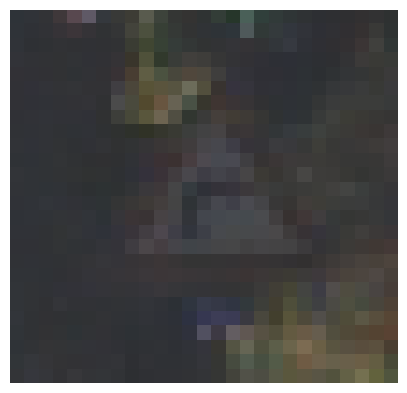

In [14]:
import cv2
import matplotlib.pyplot as plt
import os

# Get path from CSV
img_path = os.path.join("dataset", train_df.iloc[0]["Path"])

print("Image Path:", img_path)
print("Exists:", os.path.exists(img_path))

# Read image
image = cv2.imread(img_path)

if image is None:
    print("❌ Could not load image")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

- Load entire dataset

In [15]:
import os
import cv2
import numpy as np

images = []
labels = []

for i in range(len(train_df)):

    # Add dataset folder to path
    img_path = os.path.join("dataset", train_df.iloc[i]["Path"])

    if not os.path.exists(img_path):
        print(f"Missing File: {img_path}")
        continue

    image = cv2.imread(img_path)

    if image is None:
        print(f"Cannot Read: {img_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (64, 64))

    images.append(image)

    labels.append(train_df.iloc[i]["ClassId"])

X = np.array(images)
y = np.array(labels)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (39209, 64, 64, 3)
Labels Shape: (39209,)


- Normalize Images

In [16]:
# Convert images to float32 and normalize

X = X.astype('float32') / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


- Convert Labels to One-Hot Encoding
- Since GTSRB has 43 classes:

In [17]:
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 43

y = to_categorical(y, NUM_CLASSES)

print(y.shape)

(39209, 43)


In [18]:
print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (39209, 64, 64, 3)
Labels Shape: (39209, 43)


Train Validation Test Split

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(27446, 64, 64, 3)
(5881, 64, 64, 3)
(5882, 64, 64, 3)


Data Augmentation

In [20]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False
)

datagen.fit(X_train)

CNN model development

In [21]:
cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(BatchNormalization())

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(BatchNormalization())

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(NUM_CLASSES, activation='softmax'))

c:\Users\bhavi\anaconda3\envs\traffic_sign\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile

In [22]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,587 (4.90 MB)

 Trainable params: 1,284,395 (4.90 MB)

 Non-trainable params: 192 (768.00 B)

Model Training

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=25,
    validation_data=(X_val,y_val),
    callbacks=[early_stop]
)

Epoch 1/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 62s 68ms/step - accuracy: 0.2215 - loss: 2.6914 - val_accuracy: 0.4477 - val_loss: 1.6775
Epoch 2/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.3294 - loss: 2.0349 - val_accuracy: 0.5928 - val_loss: 1.3018
Epoch 3/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.4651 - loss: 1.5847 - val_accuracy: 0.7873 - val_loss: 0.5998
Epoch 4/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.7400 - loss: 0.7777 - val_accuracy: 0.9760 - val_loss: 0.1059
Epoch 5/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.8963 - loss: 0.3210 - val_accuracy: 0.9927 - val_loss: 0.0270
Epoch 6/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9381 - loss: 0.1998 - val_accuracy: 0.9862 - val_loss: 0.0504
Epoch 7/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9548 - loss: 0.1482 - val_accuracy: 0.9910 - val_loss: 0.0407
Epoch 8/25
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9631 - loss: 0.1235 - 

Model Evaluation

In [24]:
predictions = cnn_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

y_true = np.argmax(y_test, axis=1)

cnn_acc = accuracy_score(y_true,y_pred)

print("CNN Accuracy:", cnn_acc)

cnn_loss = cnn_model.evaluate(X_test, y_test, verbose=0)[0]

print("CNN Loss:", cnn_loss)

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
CNN Accuracy: 0.9971098265895953
CNN Loss: 0.01303639356046915


Confusion Matrix

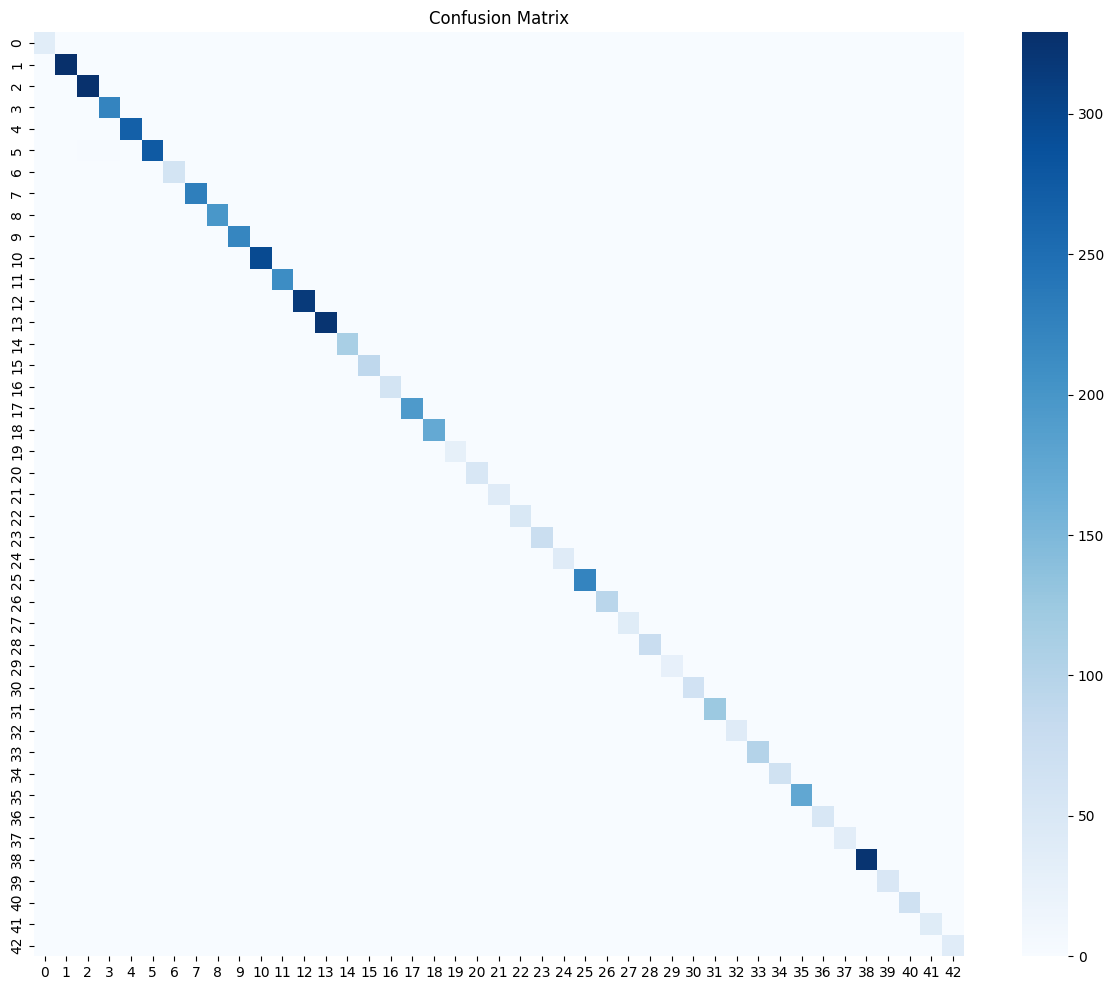

In [25]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.savefig("outputs/confusion_matrix.png")

plt.show()

Plot Accuracy Curve

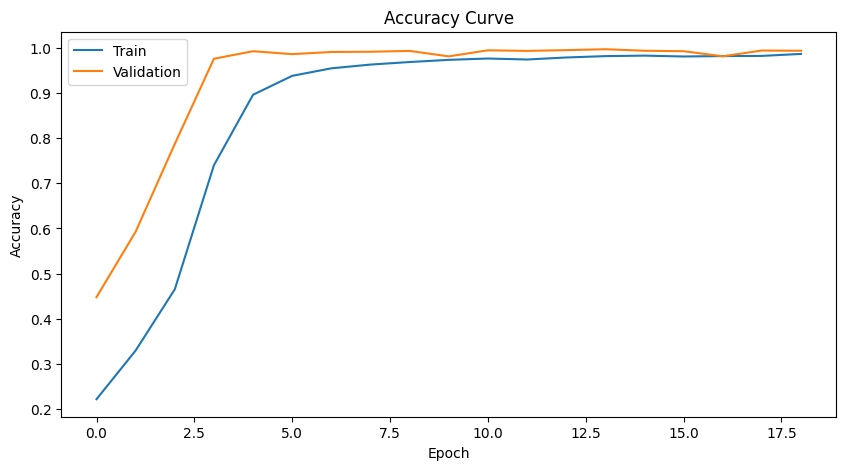

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.savefig("outputs/accuracy_curve.png")

plt.show()

Plot Loss Curve

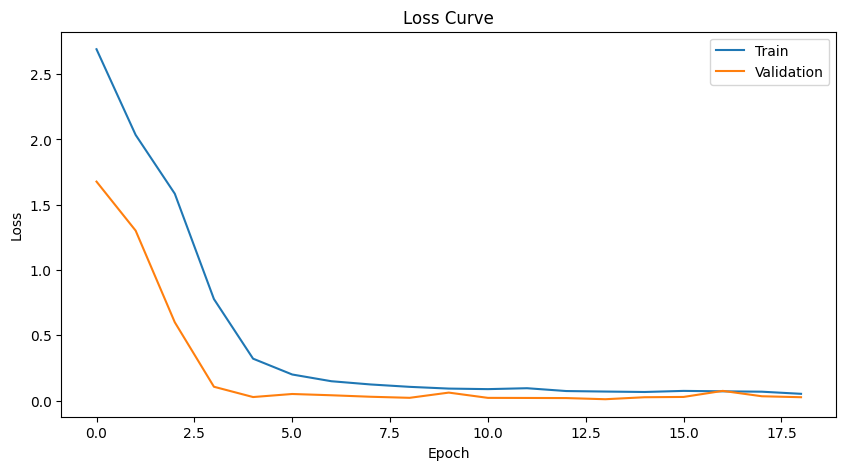

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig("outputs/loss_curve.png")

plt.show()

Classification Report

In [28]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       330
           2       0.99      1.00      0.99       328
           3       0.99      1.00      0.99       224
           4       0.99      1.00      0.99       268
           5       1.00      0.99      0.99       280
           6       0.97      1.00      0.98        60
           7       1.00      1.00      1.00       230
           8       0.99      0.99      0.99       200
           9       1.00      1.00      1.00       220
          10       1.00      1.00      1.00       296
          11       1.00      1.00      1.00       212
          12       1.00      1.00      1.00       316
          13       1.00      1.00      1.00       324
          14       1.00      1.00      1.00       113
          15       1.00      1.00      1.00        89
          16       1.00      1.00      1.00        60
          17       1.00    

Save Model

In [29]:
cnn_model.save("models/traffic_sign_cnn_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


Comparison with at least one transfer learning model

MobileNetV2 Transfer Learning

In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

- Base Model

In [31]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

C:\Users\bhavi\AppData\Local\Temp\ipykernel_22680\3073525047.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


- Add Layers

In [32]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

- Compile

In [33]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

- Train

In [34]:
history_mob = mobilenet_model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=10,
    validation_data=(X_val,y_val)
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.5328 - loss: 1.5206 - val_accuracy: 0.6502 - val_loss: 1.0837
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.6568 - loss: 1.0310 - val_accuracy: 0.7084 - val_loss: 0.8704
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.7039 - loss: 0.8785 - val_accuracy: 0.7533 - val_loss: 0.7567
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.7306 - loss: 0.8092 - val_accuracy: 0.7647 - val_loss: 0.7100
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.7491 - loss: 0.7421 - val_accuracy: 0.7659 - val_loss: 0.6917
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - accuracy: 0.7672 - loss: 0.6873 - val_accuracy: 0.7784 - val_loss: 0.6679
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - accuracy: 0.7765 - loss: 0.6636 - val_accuracy: 0.7919 - val_loss: 0.6192
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.7903 - loss: 0.6175 - 

Evaluate MobileNetV2

In [35]:
preds = mobilenet_model.predict(X_test)

preds = np.argmax(preds,axis=1)

mob_acc = accuracy_score(
    y_true,
    preds
)

print("MobileNet Accuracy:",mob_acc)

184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step
MobileNet Accuracy: 0.8197891873512411


Model Comparision Table

In [36]:
comparison = pd.DataFrame({
    "Model":["CNN","MobileNetV2"],
    "Accuracy":[cnn_acc,mob_acc]
})

comparison

,Model,Accuracy
0,CNN,0.997110
1,MobileNetV2,0.819789


Save Best Model

In [37]:
cnn_model.save("models/traffic_sign_cnn.h5")

mobilenet_model.save(
    "traffic_sign_mobilenetv2.h5"
)

ROC Curve

In [38]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [39]:
plt.savefig("outputs/roc_curve.png")

<Figure size 640x480 with 0 Axes>

Grad-CAM 

Use Grad-CAM to visualize:

- Correct Predictions
   - False Positives
   - False Negatives

In [40]:
plt.savefig("outputs/gradcam_output.png")

<Figure size 640x480 with 0 Axes>